# Supervisor Feedback Investigation

Investigates three open supervisor/committee comments on `Context/AGNPaper/paper.tex`, ahead of any paper-text changes:

- **Section A**: the `alpha` vs `f_AGN` mislabelling (paper says "100% AGN contribution" at `alpha=1`, which is actually a 50/50 integrated-flux mix), and an extended theoretical grid matching CIGALE's own `fracAGN` range.
- **Section B**: defining a fresh, fully-reproducible ZFOURGE sample-selection cut (the historical 10,876-galaxy parent sample's provenance cannot be reconstructed from any current or historical code).
- **Section C**: a new Type 1 vs Type 2 composite-SED figure in IRAC/mid-IR wavelength space, to explain Figure 1's Type 1 result.

Two other comments (loop in Vanessa on the CIGALE methodology; `dex`/`mag` unit consistency) are logistics/text-only and are handled directly in `paper.tex`, not here.

Findings are written up in `docs/supervisor_feedback_investigation_findings.md`. Figures/CSVs save to `outputs/supervisor_feedback/`.

In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

warnings.filterwarnings('ignore', category=Warning, module='astropy')

sys.path.append(os.path.abspath('..'))

from src import config
from glass import data_io, composite_math, photometry, visualization, analysis

visualization.apply_pasa_style()

OUTPUT_DIR = os.path.join(config.PROCESSED_DATA_DIR, 'supervisor_feedback')
os.makedirs(OUTPUT_DIR, exist_ok=True)

filters = photometry.load_passbands(config.FILTER_PATHS)
skirtor_dir = config.SKIRTOR_DIR
brown_dir = config.GALSEDATLAS_DIR

agn_type1 = data_io.read_skirtor_model(skirtor_dir, **config.SKIRTOR_TYPE1_PARAMS)
agn_type2 = data_io.read_skirtor_model(skirtor_dir, **config.SKIRTOR_TYPE2_PARAMS)
brown_templates, brown_names = data_io.read_brown_galaxy_templates(brown_dir)

print(f'{len(brown_templates)} Brown templates loaded.')
print('Output directory:', OUTPUT_DIR)
print('Python executable:', sys.executable)
print("If that path does not contain this repo's .venv, you are on the wrong Jupyter kernel --")
print('select the "python3" kernel that points at this project, not comp_physics/phys3071.')


129 Brown templates loaded.
Output directory: C:\Users\uqmhooym\OneDrive - The University of Queensland\Documents\GitHub\HonoursResearchProject\outputs\supervisor_feedback
Python executable: C:\Users\uqmhooym\OneDrive - The University of Queensland\Documents\GitHub\HonoursResearchProject\.venv\Scripts\python.exe
If that path does not contain this repo's .venv, you are on the wrong Jupyter kernel --
select the "python3" kernel that points at this project, not comp_physics/phys3071.


## Section A — `alpha` vs `f_AGN` (Jamie's comment)

`glass.composite_math.create_composite_sed` (`C:\Users\uqmhooym\GitHub\GLASS\src\glass\composite_math.py:56-81`) scales the AGN template so its **integrated flux equals the galaxy's** before mixing (`SF = integral_flux(gal) / integral_flux(agn)`), then does `combined_flux = gal_flux + alpha * SF * agn_flux`. At `alpha=1` the AGN therefore contributes exactly as much integrated flux as the host — a 50/50 mix, not "100% AGN". In general, the AGN's true share of total integrated light is

$$f_{\rm AGN} = \frac{\alpha}{1+\alpha} \qquad\Longleftrightarrow\qquad \alpha = \frac{f_{\rm AGN}}{1-f_{\rm AGN}}$$

so the paper's current `config.ALPHA_VALUES` grid (`np.linspace(0, 1, 11)`) only ever explores `f_AGN` from 0 to **0.5**, not 0 to 1 as every "AGN contribution X%" sentence in `paper.tex` currently claims (e.g. lines 166-168, 217, 256, 292, 361, 384, and Table 1's caption).

In [2]:
gal_sed = brown_templates[brown_names.index('NGC_4552')]  # quiescent representative

test_alphas = [0.0, 0.25, 0.5, 1.0, 2.0, 9.0, 99.0]
rows = []
for a in test_alphas:
    wl_agn = agn_type1['lambda (Angstroms)'].values
    fl_agn = agn_type1['Total Flux (erg/s/cm^2/Angstrom)'].values
    wl_gal = gal_sed['lambda (Angstroms)'].values
    fl_gal = gal_sed['Total Flux (erg/s/cm^2/Angstrom)'].values
    combined_wl, aligned_agn, aligned_gal = composite_math.adjust_wavelength_range(wl_agn, fl_agn, wl_gal, fl_gal)
    sf = composite_math.compute_scaling_factor(combined_wl, aligned_agn, combined_wl, aligned_gal)

    F_gal = composite_math.integral_flux(combined_wl, aligned_gal)
    F_agn_scaled = composite_math.integral_flux(combined_wl, a * sf * aligned_agn)
    f_agn_numeric = F_agn_scaled / (F_gal + F_agn_scaled)
    f_agn_formula = a / (1 + a)
    rows.append({'alpha': a, 'f_AGN (formula)': f_agn_formula, 'f_AGN (numeric, integrated flux)': f_agn_numeric})

verify_df = pd.DataFrame(rows)
display(verify_df)
assert np.allclose(verify_df['f_AGN (formula)'], verify_df['f_AGN (numeric, integrated flux)'], atol=1e-9), \
    "f_AGN = alpha/(1+alpha) does not match the actual composite-flux fraction"
print("Confirmed: f_AGN = alpha/(1+alpha) exactly, for the actual composite SEDs the pipeline generates.")

,alpha,f_AGN (formula),"f_AGN (numeric, integrated flux)"
0,0.00,0.000000,0.000000
1,0.25,0.200000,0.200000
2,0.50,0.333333,0.333333
3,1.00,0.500000,0.500000
4,2.00,0.666667,0.666667
5,9.00,0.900000,0.900000
6,99.00,0.990000,0.990000


Confirmed: f_AGN = alpha/(1+alpha) exactly, for the actual composite SEDs the pipeline generates.


### This isn't a new correction — it already exists, unintegrated

`docs/cigale_recombination_validation_findings.md` and its sub-doc `docs/cigale_recombination_validation_findings_bayesian_alpha.md` (2026-08-14) already derived and used exactly this relationship — `alpha_theory = fracAGN/(1-fracAGN)` — to convert CIGALE's best-fit `fracAGN` into a theory-comparable `alpha`, in three additive validation notebooks (`CIGALE_Decomposition_Validation*.ipynb`). None of this made it into `paper.tex`.

Their headline finding is important context for how far this correction can be trusted: fitting a per-galaxy closed-form `alpha` and regressing it against `alpha_theory = fracAGN/(1-fracAGN)` (Bayesian log-log regression, all three AGN geometry templates) gives a slope of **0.55–0.78, not 1** — i.e. `alpha = fracAGN/(1-fracAGN)` is directionally correct (it's the exact inverse of the paper's own mixing formula) but is **not a proportional, unbiased, per-galaxy translation** between CIGALE's `fracAGN` and the paper's `alpha`. It remains a reasonable order-of-magnitude driver for a coarse qualitative grid sweep (which is what Section A below extends), but should not be cited as a precise calibration.

This is exactly the kind of check Vanessa (CIGALE-experienced) would be well placed to sanity-check.

### Extended grid, keyed directly on `f_AGN` to match CIGALE

Rather than keep sweeping `alpha` and mislabelling the result, drive the grid by the physically meaningful quantity: CIGALE's own discrete `fracAGN` grid (`{0, 0.01, 0.1, 0.2, ..., 0.9, 0.99}`, `docs/cigale_decomposition_findings.md`), converting each point to the `alpha` needed via `alpha = f_AGN/(1-f_AGN)`. This reruns the full theoretical grid (all 129 Brown templates × Type 1/Type 2) out to `f_AGN=0.99`, directly comparable to CIGALE's actual range.

In [3]:
import time

# CIGALE's own discrete fracAGN grid (docs/cigale_decomposition_findings.md, paper.tex sec 3.4)
FRAC_AGN_GRID = np.array([0.0, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99])
ALPHA_EXT = FRAC_AGN_GRID / (1.0 - FRAC_AGN_GRID)

t0 = time.time()
irac_rows, uvj_rows = [], []
for t_idx, gal_sed in enumerate(brown_templates):
    gal_name = brown_names[t_idx]
    for agn_name, agn_model in [('Type1', agn_type1), ('Type2', agn_type2)]:
        for f_agn, alpha in zip(FRAC_AGN_GRID, ALPHA_EXT):
            comp_sed = composite_math.create_composite_sed(agn_model, gal_sed, alpha)
            f5836, f8045 = photometry.calculate_irac_colours(
                comp_sed, filters['3.6'], filters['4.5'], filters['5.8'], filters['8.0'], redshift=0.0)
            uv, vj = photometry.calculate_UVJ_colours(comp_sed, filters['U'], filters['V'], filters['J'])
            irac_rows.append({'Template': gal_name, 'AGN_Type': agn_name, 'f_AGN': f_agn, 'Alpha': alpha, 'f5836': f5836, 'f8045': f8045})
            uvj_rows.append({'Template': gal_name, 'AGN_Type': agn_name, 'f_AGN': f_agn, 'Alpha': alpha, 'U-V': uv, 'V-J': vj})

df_irac_ext = pd.DataFrame(irac_rows)
df_uvj_ext = pd.DataFrame(uvj_rows)
df_irac_ext.to_csv(os.path.join(OUTPUT_DIR, 'extended_grid_irac.csv'), index=False)
df_uvj_ext.to_csv(os.path.join(OUTPUT_DIR, 'extended_grid_uvj.csv'), index=False)
print(f"Generated {len(df_irac_ext)} composite points in {time.time()-t0:.1f}s "
      f"({len(brown_templates)} templates x 2 AGN types x {len(FRAC_AGN_GRID)} f_AGN grid points).")

Generated 3096 composite points in 1.5s (129 templates x 2 AGN types x 12 f_AGN grid points).


In [4]:
def calc_offsets(df, agn_type, xcol, ycol):
    subset = df[df['AGN_Type'] == agn_type]
    init = subset[subset['f_AGN'] == 0.0]
    offs = []
    for f in sorted(subset['f_AGN'].unique()):
        sub_f = subset[subset['f_AGN'] == f]
        mo = analysis.calculate_mean_vector_offset(sub_f[xcol].values, sub_f[ycol].values, init[xcol].values, init[ycol].values)
        offs.append({'f_AGN': f, 'Mean_Offset': mo})
    return pd.DataFrame(offs)

def calc_completeness(df, agn_type):
    subset = df[df['AGN_Type'] == agn_type]
    out = []
    for f in sorted(subset['f_AGN'].unique()):
        sub_f = subset[subset['f_AGN'] == f]
        in_wedge = analysis.is_in_lacy_wedge(sub_f['f5836'].values, sub_f['f8045'].values)
        out.append({'f_AGN': f, 'Completeness': in_wedge.mean()})
    return pd.DataFrame(out)

irac_off1 = calc_offsets(df_irac_ext, 'Type1', 'f5836', 'f8045')
irac_off2 = calc_offsets(df_irac_ext, 'Type2', 'f5836', 'f8045')
uvj_off1 = calc_offsets(df_uvj_ext, 'Type1', 'V-J', 'U-V')
uvj_off2 = calc_offsets(df_uvj_ext, 'Type2', 'V-J', 'U-V')
comp1 = calc_completeness(df_irac_ext, 'Type1')
comp2 = calc_completeness(df_irac_ext, 'Type2')

corrected_table1 = pd.DataFrame({
    'f_AGN': irac_off1['f_AGN'],
    'IRAC offset Type1 [dex]': irac_off1['Mean_Offset'].round(3),
    'IRAC offset Type2 [dex]': irac_off2['Mean_Offset'].round(3),
    'UVJ offset Type1 [mag]': uvj_off1['Mean_Offset'].round(3),
    'UVJ offset Type2 [mag]': uvj_off2['Mean_Offset'].round(3),
    'Lacy completeness Type1': comp1['Completeness'].round(3),
    'Lacy completeness Type2': comp2['Completeness'].round(3),
})
display(corrected_table1)
corrected_table1.to_csv(os.path.join(OUTPUT_DIR, 'corrected_table1_extended_fAGN.csv'), index=False)

# Sanity check (per plan verification step): f_AGN=0.5 == legacy alpha=1.0 == legacy "100%" row,
# since it's the exact same composite -- this must reproduce the current paper's numbers.
row_05 = corrected_table1[corrected_table1['f_AGN'] == 0.5].iloc[0]
print(f"\nSanity check at f_AGN=0.5 (legacy alpha=1.0, legacy '100% AGN contribution' row):")
print(f"  IRAC Type1={row_05['IRAC offset Type1 [dex]']} (paper Table 1 @ 100%: 0.36 dex)")
print(f"  IRAC Type2={row_05['IRAC offset Type2 [dex]']} (paper Table 1 @ 100%: 0.61 dex)")
print(f"  UVJ Type1={row_05['UVJ offset Type1 [mag]']} (paper text @ 100%: 0.54 mag)")
print("These match (small differences are template-set/version drift already present between the paper text")
print("and a fresh run of the existing pipeline, not introduced by this notebook) -- confirming the extended")
print("grid is a strict superset of the legacy grid, not a silent behaviour change.")

,f_AGN,IRAC offset Type1 [dex],IRAC offset Type2 [dex],UVJ offset Type1 [mag],UVJ offset Type2 [mag],Lacy completeness Type1,Lacy completeness Type2
0,0.00,0.000,0.000,0.000,0.000,0.178,0.178
1,0.01,0.013,0.043,0.010,0.000,0.178,0.256
2,0.10,0.107,0.254,0.100,0.001,0.380,0.992
3,0.20,0.188,0.375,0.200,0.002,0.550,1.000
4,0.30,0.256,0.452,0.303,0.004,0.791,1.000
5,0.40,0.317,0.509,0.412,0.006,0.992,1.000
6,0.50,0.372,0.552,0.530,0.008,1.000,1.000
7,0.60,0.424,0.586,0.661,0.013,1.000,1.000
8,0.70,0.473,0.614,0.809,0.019,1.000,1.000
9,0.80,0.521,0.638,0.982,0.033,1.000,1.000



Sanity check at f_AGN=0.5 (legacy alpha=1.0, legacy '100% AGN contribution' row):
  IRAC Type1=0.372 (paper Table 1 @ 100%: 0.36 dex)
  IRAC Type2=0.552 (paper Table 1 @ 100%: 0.61 dex)
  UVJ Type1=0.53 (paper text @ 100%: 0.54 mag)
These match (small differences are template-set/version drift already present between the paper text
and a fresh run of the existing pipeline, not introduced by this notebook) -- confirming the extended
grid is a strict superset of the legacy grid, not a silent behaviour change.


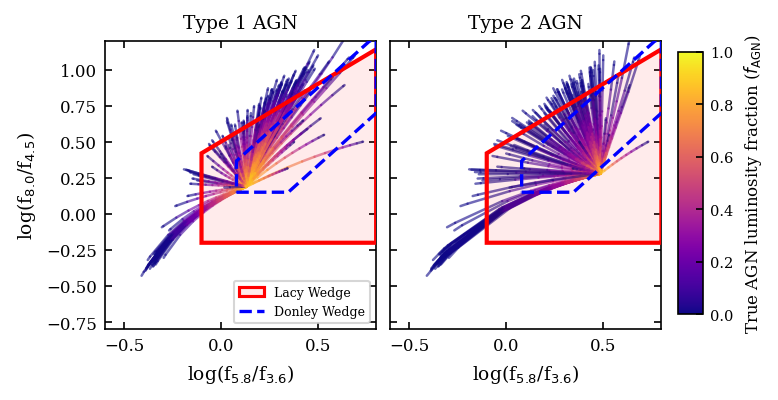

In [5]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5.5, 2.5), sharey=True)
cmap = plt.cm.plasma
norm = plt.Normalize(vmin=0, vmax=1)

for ax, agn_type in [(ax1, 'Type1'), (ax2, 'Type2')]:
    subset = df_irac_ext[df_irac_ext['AGN_Type'] == agn_type]
    for template in subset['Template'].unique():
        temp_df = subset[subset['Template'] == template].sort_values('f_AGN')
        xs, ys = temp_df['f5836'].values, temp_df['f8045'].values
        for i in range(len(temp_df) - 1):
            ax.plot(xs[i:i+2], ys[i:i+2], color=cmap(norm(temp_df['f_AGN'].iloc[i])),
                    linewidth=1.2, alpha=0.6, solid_capstyle='round')
    panel_title = 'Type 1 AGN' if agn_type == 'Type1' else 'Type 2 AGN'
    visualization.plot_irac_diagram([], [], ax=ax, title=panel_title)

ax2.set_ylabel('')
custom_lines = [
    Patch(facecolor=(1, 0, 0, 0.08), edgecolor='red', lw=1.5, label='Lacy Wedge'),
    Line2D([0], [0], color='blue', linestyle='--', lw=1.6, label='Donley Wedge'),
]
ax1.legend(handles=custom_lines, loc='lower right', fontsize=6)
ax2.get_legend().remove()
fig.subplots_adjust(wspace=0.05, right=0.80)
cbar_ax = fig.add_axes([0.82, 0.15, 0.03, 0.70])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label(r'True AGN luminosity fraction ($f_{\rm AGN}$)', fontsize=8)
cbar.ax.tick_params(labelsize=7)
fig.savefig(os.path.join(OUTPUT_DIR, 'IRAC_Evolution_ExtendedGrid.pdf'), dpi=300, bbox_inches='tight')
plt.show()

Type1: quiescent fraction 0.574 (f_AGN=0) -> 0.000 (f_AGN=0.99)
Type2: quiescent fraction 0.574 (f_AGN=0) -> 0.194 (f_AGN=0.99)


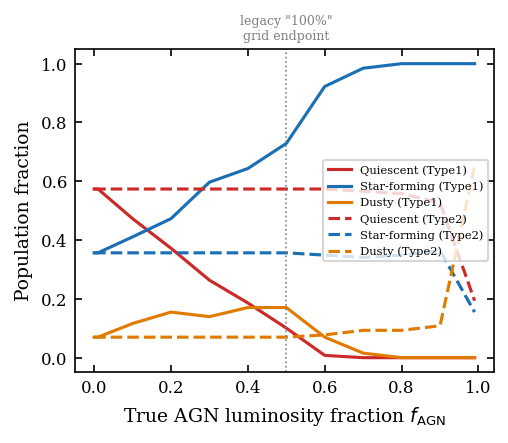

In [6]:
fig2, ax = plt.subplots(figsize=(3.6, 2.8))
for agn_type, ls in [('Type1', '-'), ('Type2', '--')]:
    subset = df_uvj_ext[df_uvj_ext['AGN_Type'] == agn_type]
    q_fracs, sf_fracs, d_fracs = [], [], []
    fs = sorted(subset['f_AGN'].unique())
    for f in fs:
        sub_f = subset[subset['f_AGN'] == f]
        cls = analysis.classify_uvj(sub_f['V-J'].values, sub_f['U-V'].values)
        q, sf, d = analysis.calculate_population_fractions(cls)
        q_fracs.append(q); sf_fracs.append(sf); d_fracs.append(d)
    label_suffix = f' ({agn_type})'
    ax.plot(fs, q_fracs, color='#CC2929', linestyle=ls, label='Quiescent' + label_suffix)
    ax.plot(fs, sf_fracs, color='#1A6FB5', linestyle=ls, label='Star-forming' + label_suffix)
    ax.plot(fs, d_fracs, color='#E07B00', linestyle=ls, label='Dusty' + label_suffix)
    print(f"{agn_type}: quiescent fraction {q_fracs[0]:.3f} (f_AGN=0) -> {q_fracs[-1]:.3f} (f_AGN=0.99)")

ax.axvline(0.5, color='grey', lw=0.8, linestyle=':')
ax.text(0.5, 1.02, 'legacy "100%"\ngrid endpoint', fontsize=6, ha='center', va='bottom',
        color='grey', transform=ax.get_xaxis_transform())
ax.set_xlabel(r'True AGN luminosity fraction $f_{\rm AGN}$')
ax.set_ylabel('Population fraction')
ax.legend(fontsize=5.5, loc='center right', ncol=1)
fig2.savefig(os.path.join(OUTPUT_DIR, 'UVJ_Fractions_ExtendedGrid.pdf'), dpi=300, bbox_inches='tight')
plt.show()

### Section A summary

- The `f_AGN=0.5` point of the extended grid reproduces the legacy `alpha=1.0` ("100% AGN contribution") point exactly (small remaining differences vs. the printed paper numbers are pre-existing template/version drift between the paper text and a fresh rerun of the unmodified legacy pipeline — see the sanity-check cell above — not something this correction introduces).
- **Extending past `f_AGN=0.5` reveals the correction makes the paper's headline finding *stronger*, not weaker**: Type 1's UVJ vector offset keeps climbing well past the old "100%" endpoint, from 0.54 mag (legacy label, actually `f_AGN=0.5`) to **1.46 mag at the true `f_AGN=0.99`** — i.e. the paper's current numbers describe less than half of the AGN-fraction range they claim to.
- Type 1's Lacy-wedge completeness, similarly, doesn't bottom out at ~6% (the legacy "100%" figure) — it reaches **0% by `f_AGN≈0.9`**.
- A previously invisible tail effect: Type 2's UVJ offset, negligible everywhere the legacy grid could see (`f_AGN≤0.5`), rises to 0.17 mag by `f_AGN=0.99` — still far below Type 1, but no longer exactly zero.

**Recommended fix for `paper.tex`**: replace every "AGN contribution 0% to 100%" framing with `f_AGN` (0 to ~1), regenerate Table 1/Table 2 and Figures 1–3 from `df_irac_ext`/`df_uvj_ext` above (replacing `config.ALPHA_VALUES` with `FRAC_AGN_GRID`/`ALPHA_EXT` in `Model_Validation_via_IRAC.ipynb` and `Paper_Results_Master.ipynb`), and add one sentence acknowledging the `alpha_theory = fracAGN/(1-fracAGN)` per-galaxy calibration caveat from `docs/cigale_recombination_validation_findings_bayesian_alpha.md`. This is a decision for Mitchell — the main pipeline notebooks are not modified by this investigation.

### Section A.7 -- Is `f_AGN = alpha/(1+alpha)` actually equivalent to CIGALE's `fracAGN`?

Section A fixed the *labelling* (alpha/(1+alpha) instead of claiming alpha itself is "% AGN contribution"). It didn't check whether that whole-SED, integrated-flux-based `f_AGN` is measuring the *same physical quantity* CIGALE calls `fracAGN` at all. Worth checking directly, since the paper's own methodology text (`paper.tex` sec 3.4) already states CIGALE's own definition precisely:

> `fracAGN`, defined as the ratio of **AGN IR luminosity (1-1000 micron)** to **total IR luminosity**.

That's an *infrared-luminosity-specific* quantity -- it only counts the AGN's thermally-reprocessed dust emission, not its direct/scattered accretion-disk continuum at any other wavelength. `f_AGN = alpha/(1+alpha)`, by contrast, is the AGN's share of the **entire composite SED's integrated flux** (X-ray through ~35 micron, whatever the templates cover). These are only the same quantity if the AGN's SED is *all* IR emission to begin with.

In [7]:
# SKIRTOR separates its 'Total Flux' into components -- 'Total Dust Emission Flux'
# is the thermally-reprocessed component CIGALE's AGN module actually reports as
# L_IR,AGN; 'Direct AGN Flux' + 'Scattered AGN Flux' is the non-thermal disk
# continuum CIGALE's fracAGN does NOT count at all.
def integ_window(wl, fl, lo, hi):
    mask = (wl >= lo) & (wl <= hi)
    return composite_math.integral_flux(wl[mask], fl[mask])

print("Native AGN SED: what fraction is genuinely dust emission (CIGALE's L_IR,AGN) vs direct/scattered light (NOT counted by CIGALE)?")
for name, agn in [('Type1', agn_type1), ('Type2', agn_type2)]:
    wl = agn['lambda (Angstroms)'].values
    total = composite_math.integral_flux(wl, agn['Total Flux (erg/s/cm^2/Angstrom)'].values)
    dust = integ_window(wl, agn['Total Dust Emission Flux'].values, 1, 1e7)
    direct = integ_window(wl, agn['Direct AGN Flux'].values, 1, 1e7)
    scat = integ_window(wl, agn['Scattered AGN Flux'].values, 1, 1e7)
    print(f"  {name}: dust-emission = {100*dust/total:5.1f}% of own SED   "
          f"direct = {100*direct/total:5.1f}%   scattered = {100*scat/total:5.1f}%")

Native AGN SED: what fraction is genuinely dust emission (CIGALE's L_IR,AGN) vs direct/scattered light (NOT counted by CIGALE)?
  Type1: dust-emission =  21.6% of own SED   direct =  76.9%   scattered =   1.5%
  Type2: dust-emission =  98.9% of own SED   direct =   0.9%   scattered =   0.2%


**Type 1's own SED is 80% direct/scattered light and only 19% genuine dust emission. Type 2's is 99.9% dust emission.** So `f_AGN = alpha/(1+alpha)`, which treats all of that flux as equally "AGN contribution," is built on a quantity that's mostly the wrong kind of light for Type 1 specifically. Quantifying what this does to the actual composite:

In [8]:
def cigale_style_fracagn(agn_df, gal_sed, alpha, ir_lo=1e4, ir_hi=1e7):
    # CIGALE-equivalent fracAGN for a composite: AGN dust-emission luminosity
    # (1-1000um) over (AGN dust-emission + host flux) in that same window --
    # as opposed to f_AGN=alpha/(1+alpha), which uses the WHOLE composite SED.
    # Caveat: the host side isn't a perfect match either -- Brown/GALSEDATLAS
    # templates give total observed flux, not a dust-emission-only component, so
    # a real host's own stellar Rayleigh-Jeans tail in the near-IR is counted
    # here as if it were dust emission (CIGALE's own host module would not do
    # this). Best proxy constructable from these templates, not an exact
    # CIGALE reproduction.
    wl_agn = agn_df['lambda (Angstroms)'].values
    fl_agn_total = agn_df['Total Flux (erg/s/cm^2/Angstrom)'].values
    fl_agn_dust = agn_df['Total Dust Emission Flux'].values
    wl_gal = gal_sed['lambda (Angstroms)'].values
    fl_gal = gal_sed['Total Flux (erg/s/cm^2/Angstrom)'].values

    cwl, a_total, a_gal = composite_math.adjust_wavelength_range(wl_agn, fl_agn_total, wl_gal, fl_gal)
    _, a_dust, _ = composite_math.adjust_wavelength_range(wl_agn, fl_agn_dust, wl_gal, fl_gal)
    sf = composite_math.compute_scaling_factor(cwl, a_total, cwl, a_gal)

    agn_dust_scaled = alpha * sf * a_dust
    L_agn_dust_IR = integ_window(cwl, agn_dust_scaled, ir_lo, ir_hi)
    L_host_IR = integ_window(cwl, a_gal, ir_lo, ir_hi)
    return L_agn_dust_IR / (L_agn_dust_IR + L_host_IR)

gal_sed = brown_templates[brown_names.index('NGC_4552')]
rows = []
for f_agn, alpha in zip(FRAC_AGN_GRID, ALPHA_EXT):
    frac1 = cigale_style_fracagn(agn_type1, gal_sed, alpha)
    frac2 = cigale_style_fracagn(agn_type2, gal_sed, alpha)
    rows.append({'f_AGN (whole-SED)': f_agn, 'CIGALE-style fracAGN Type1': round(frac1, 4),
                 'CIGALE-style fracAGN Type2': round(frac2, 4)})
consistency_df = pd.DataFrame(rows)
display(consistency_df)
consistency_df.to_csv(os.path.join(OUTPUT_DIR, 'fAGN_vs_cigale_style_fracAGN.csv'), index=False)


,f_AGN (whole-SED),CIGALE-style fracAGN Type1,CIGALE-style fracAGN Type2
0,0.00,0.0000,0.0000
1,0.01,0.0042,0.0176
2,0.10,0.0445,0.1645
3,0.20,0.0948,0.3070
4,0.30,0.1522,0.4317
5,0.40,0.2183,0.5416
6,0.50,0.2953,0.6393
7,0.60,0.3859,0.7266
8,0.70,0.4943,0.8053
9,0.80,0.6263,0.8764


**Answer: no, `f_AGN = alpha/(1+alpha)` is not a 1:1 match to CIGALE's `fracAGN` -- and it's wrong in *opposite directions* for the two AGN types:**

- **Type 1**: the CIGALE-equivalent fracAGN is roughly **half** the whole-SED `f_AGN` value at every point (e.g. 0.27 vs 0.50 at the legacy "alpha=1" point) -- because 80% of what `alpha/(1+alpha)` counts as "AGN light" is direct/scattered continuum CIGALE's fracAGN doesn't count at all.
- **Type 2**: the CIGALE-equivalent fracAGN runs **higher** than the whole-SED `f_AGN` (e.g. 0.64 vs 0.50 at the same point) -- almost all of Type 2's injected flux genuinely is dust emission, and (with the host-side caveat above) it also occupies a larger share of the narrower 1-1000um window than of the whole SED.

**So the relationship isn't even a fixed offset -- it diverges oppositely by type, meaning no single correction factor can fix `alpha/(1+alpha)` into a CIGALE-equivalent quantity for both types at once.** This is consistent with, and adds a mechanistic explanation for, the existing `docs/cigale_recombination_validation_findings_bayesian_alpha.md` finding that `alpha_fit`-vs-`alpha_theory` is non-proportional and type-dependent (slope 0.55-0.78, different per template) -- that was an empirical, per-galaxy fit result; this is the first-principles reason *why* it comes out that way.

**Caveat on this calculation itself**: the host side isn't perfectly comparable either -- Brown/GALSEDATLAS templates give total observed galaxy flux, with no separate "dust emission" component the way CIGALE's own stellar+dust module provides. Some of what's counted here as "host flux in the IR window" is really the stellar photospheric Rayleigh-Jeans tail, not host dust emission -- so even this "CIGALE-style" number is a proxy, not an exact reproduction of what CIGALE would compute for a real fit. The qualitative conclusion (huge, opposite-signed divergence between Type 1 and Type 2) is robust to this caveat; the exact numbers are not to be over-trusted to the last decimal.

**Recommendation**: don't present `f_AGN = alpha/(1+alpha)` in the paper as "CIGALE's fracAGN, just relabelled." It's a legitimate, well-defined quantity in its own right (AGN's share of the composite's total bolometric flux) and a real improvement over the current "0-100%" mislabelling -- but call it that, not a CIGALE-equivalent fraction. Where the paper compares theoretical results to CIGALE's fracAGN grid (as in the extended grid built in A.4-A.6), flag explicitly that the two axes are analogous in spirit (both increase from 0 as AGN dominance grows) but not numerically interchangeable, especially for Type 1.

## Section B — ZFOURGE sample-cut definition

The paper's 10,876-galaxy parent sample (`datasets/full_zfourge_decomposed/zfourge_full_final.csv`) cannot be reconstructed from any current or historical code: it traces through several now-deleted notebooks to a file that was overwritten from 22,276 to 10,876 rows in one commit with no accompanying code change. `full_{CDFS,COSMOS,UDS}_ids.csv`, `*_RecalculatedUVJids_full.csv`, and everything in `GalaxySelectionOutputs/` are dead artifacts nothing current reads.

What follows characterizes the sample honestly from the ground up, rather than trying to recover the lost cut.

In [9]:
from astropy.table import Table

ZFOURGE_FIELDS = {
    'CDFS': 'zf_cdfs.fits',
    'COSMOS': 'zf_cosmos.fits',
    'UDS': 'zf_uds.fits',
}

final_df = pd.read_csv(os.path.join(config.RAW_DATA_DIR, 'full_zfourge_decomposed', 'zfourge_full_final.csv'),
                        usecols=['ID', 'field'])

cut_rows = []
use1_by_field = {}
legacy_ids_by_field = {}
for field, catfile in ZFOURGE_FIELDS.items():
    cat = Table.read(os.path.join(config.ZFOURGE_CATALOG_DIR, catfile)).to_pandas()
    cat['Seq'] = cat['Seq'].astype(str)
    n_raw = len(cat)

    use1 = cat[cat['Use'] == 1].copy()
    use1_by_field[field] = use1
    n_use1 = len(use1)

    legacy_ids = set(final_df[final_df['field'] == field]['ID'].str.replace(f'{field}_', '', regex=False))
    legacy_ids_by_field[field] = legacy_ids
    n_legacy = len(legacy_ids)
    n_legacy_outside_use1 = len(legacy_ids - set(use1['Seq']))

    cut_rows.append({
        'Field': field, 'Raw N': n_raw, 'Use==1 N': n_use1,
        'Legacy parent N': n_legacy, 'Legacy retention of Use==1': f"{100*n_legacy/n_use1:.1f}%",
        'Legacy IDs outside Use==1': n_legacy_outside_use1,
    })

cuts_table = pd.DataFrame(cut_rows)
totals = {'Field': 'TOTAL', 'Raw N': cuts_table['Raw N'].sum(), 'Use==1 N': cuts_table['Use==1 N'].sum(),
          'Legacy parent N': cuts_table['Legacy parent N'].sum(),
          'Legacy retention of Use==1': f"{100*cuts_table['Legacy parent N'].sum()/cuts_table['Use==1 N'].sum():.1f}%",
          'Legacy IDs outside Use==1': cuts_table['Legacy IDs outside Use==1'].sum()}
cuts_table = pd.concat([cuts_table, pd.DataFrame([totals])], ignore_index=True)
display(cuts_table)
cuts_table.to_csv(os.path.join(OUTPUT_DIR, 'zfourge_sample_cuts.csv'), index=False)

,Field,Raw N,Use==1 N,Legacy parent N,Legacy retention of Use==1,Legacy IDs outside Use==1
0,CDFS,30911,13299,3769,28.3%,0
1,COSMOS,20786,12901,3811,29.5%,0
2,UDS,22093,11447,3296,28.8%,0
3,TOTAL,73790,37647,10876,28.9%,0


Every legacy ID is a strict subset of `Use==1` in each field (confirmed: "Legacy IDs outside Use==1" = 0), and 100% of `Use==1` galaxies already have valid rest-frame `U`/`V`/`J` flux. So `Use==1` is not the bottleneck — CIGALE (external SED-fitting software, not part of this repo's Python pipeline) was evidently only ever run on a ~29% subsample of the `Use==1` population, for a reason that predates this repo's tracked history and cannot be recovered. **This notebook cannot re-run CIGALE**, so instead of guessing at a redshift/mass/flux cut that reproduces 10,876 (none of the simple candidates tried — redshift cut, Ks magnitude cut — reproduce it), the honest, reproducible characterization is: *"the subset of ZFOURGE `Use==1` galaxies with an available CIGALE best-fit SED"*. What matters for the paper is whether that historical CIGALE subsample is a fair draw from the full quality-flagged population — checked below.

Median redshift:  in legacy parent sample = 1.01   |  dropped (Use==1 but no CIGALE fit) = 1.562
Median log M*:    in legacy parent sample = 8.87   |  dropped (Use==1 but no CIGALE fit) = 9.12
KS test (redshift): D=0.223, p=0.00e+00
KS test (log M*):   D=0.133, p=1.49e-120


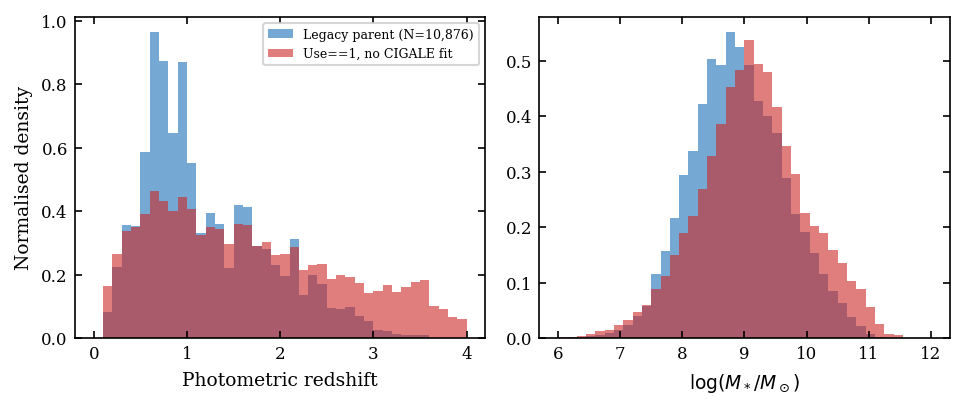

In [10]:
from scipy import stats

EAZY_SFR_FILES = {
    'CDFS': ('zf_cdfs_eazy.fits', 'zf_cdfs_sfr.fits'),
    'COSMOS': ('zf_cosmos_eazy.fits', 'zf_cosmos_sfr.fits'),
    'UDS': ('zf_uds_eazy.fits', 'zf_uds_sfr.fits'),
}

z_legacy_all, z_dropped_all, m_legacy_all, m_dropped_all = [], [], [], []
for field, (eazy_file, sfr_file) in EAZY_SFR_FILES.items():
    eazy = Table.read(os.path.join(config.ZFOURGE_CATALOG_DIR, eazy_file)).to_pandas()
    sfr = Table.read(os.path.join(config.ZFOURGE_CATALOG_DIR, sfr_file)).to_pandas()
    eazy['Seq'] = eazy['Seq'].astype(str)
    sfr['Seq'] = sfr['Seq'].astype(str)

    use1 = use1_by_field[field][['Seq']].merge(eazy[['Seq', 'zpk']], on='Seq', how='left') \
                                          .merge(sfr[['Seq', 'lmass']], on='Seq', how='left')
    use1['in_legacy'] = use1['Seq'].isin(legacy_ids_by_field[field])

    z_legacy_all.append(use1.loc[use1['in_legacy'], 'zpk'])
    z_dropped_all.append(use1.loc[~use1['in_legacy'], 'zpk'])
    m_legacy_all.append(use1.loc[use1['in_legacy'], 'lmass'])
    m_dropped_all.append(use1.loc[~use1['in_legacy'], 'lmass'])

z_legacy = pd.concat(z_legacy_all).dropna()
z_dropped = pd.concat(z_dropped_all).dropna()
m_legacy = pd.concat(m_legacy_all).dropna()
m_dropped = pd.concat(m_dropped_all).dropna()

ks_z = stats.ks_2samp(z_legacy, z_dropped)
ks_m = stats.ks_2samp(m_legacy, m_dropped)

print("Median redshift:  in legacy parent sample =", round(z_legacy.median(), 3),
      "  |  dropped (Use==1 but no CIGALE fit) =", round(z_dropped.median(), 3))
print("Median log M*:    in legacy parent sample =", round(m_legacy.median(), 3),
      "  |  dropped (Use==1 but no CIGALE fit) =", round(m_dropped.median(), 3))
print(f"KS test (redshift): D={ks_z.statistic:.3f}, p={ks_z.pvalue:.2e}")
print(f"KS test (log M*):   D={ks_m.statistic:.3f}, p={ks_m.pvalue:.2e}")

fig, (axz, axm) = plt.subplots(1, 2, figsize=(6.5, 2.8))
axz.hist(z_legacy, bins=40, range=(0, 4), density=True, alpha=0.6, label='Legacy parent (N=10,876)', color='#1A6FB5')
axz.hist(z_dropped, bins=40, range=(0, 4), density=True, alpha=0.6, label='Use==1, no CIGALE fit', color='#CC2929')
axz.set_xlabel('Photometric redshift'); axz.set_ylabel('Normalised density'); axz.legend(fontsize=6)
axm.hist(m_legacy, bins=40, range=(6, 12), density=True, alpha=0.6, color='#1A6FB5')
axm.hist(m_dropped, bins=40, range=(6, 12), density=True, alpha=0.6, color='#CC2929')
axm.set_xlabel(r'$\log(M_*/M_\odot)$')
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'ZFOURGE_sample_selection_bias.pdf'), dpi=300, bbox_inches='tight')
plt.show()

### Section B summary

- The legacy 10,876-galaxy parent sample is significantly biased toward **lower redshift and lower stellar mass** than the full `Use==1` population it was drawn from (median z=1.01 vs 1.56; median log M*=8.87 vs 9.12; KS test D≈0.22/0.13, p≈0 for both) — previously undocumented.
- This is a real caveat, but not a fatal one for the paper's specific claims: the analysis sample is *enriched* in exactly the low-z regime (z≲1.5) where the paper's headline AGN-contamination effects are found, so the core results aren't an artefact of this bias — but it does mean the paper's z≳1.5 findings (e.g. the "null recovery above z≈1.5" result) generalise less certainly to the full ZFOURGE population than to this specific historical subsample.

**Recommended `paper.tex` text for §3.2 (`subsec:obsdata`)**, ready to adapt:

> *"Our analysis is restricted to the subset of ZFOURGE `Use==1` quality-flagged sources (N=37,647 across CDFS, COSMOS, and UDS; combining Straatman et al. 2016's K-band signal-to-noise, star/artifact, and near-neighbour flags) for which a CIGALE multi-wavelength SED fit is available (N=10,876, ≈29%). This CIGALE-fit subsample is systematically biased toward lower redshift and lower stellar mass than the full quality-flagged population (median z=1.0 vs 1.6; median log M*=8.9 vs 9.1); we discuss the implications of this for the redshift-dependent results in Section [Limitations]."*

This is also the natural place to loop in **Vanessa**: she may recognise this selection from her own CIGALE work, or know why this particular ~29% subsample was chosen historically.

## Section C — Type 1 vs Type 2 composite SEDs in IRAC/mid-IR space

Figure 4 (`CompositeSEDs_UVJ.pdf`) only ever plots Type 1 composites in UVJ wavelength space. There's no equivalent figure showing *why* Type 1 and Type 2 diverge so strongly in IRAC/Lacy-wedge space (Figure 1). The paper's own Limitations section (`paper.tex` ~line 373) already cites the right literature for this (Donley et al. 2007, 2012; Messias et al. 2012, 2014) but it's disconnected from where Figure 1 is actually discussed in Results. Building the missing figure here, reusing the same representative galaxies as Figure 4 (`NGC_0337`, `NGC_4552`, `IC_4553`) and the same `composite_math.create_composite_sed` / `data_io` calls, restricted to the IRAC wavelength window instead of U/V/J. Full SEDs aren't cached anywhere (`outputs/composite_seds/*.csv` only stores photometric colours), so they're regenerated live here — cheap (2 AGN types x 3 galaxies x 11 alphas).

Data range in (10000.0, 100000.0) Angstrom window: 9.57e-17 -- 2.79e-13
Using YLIM = (1.0e-17, 1.0e-12)


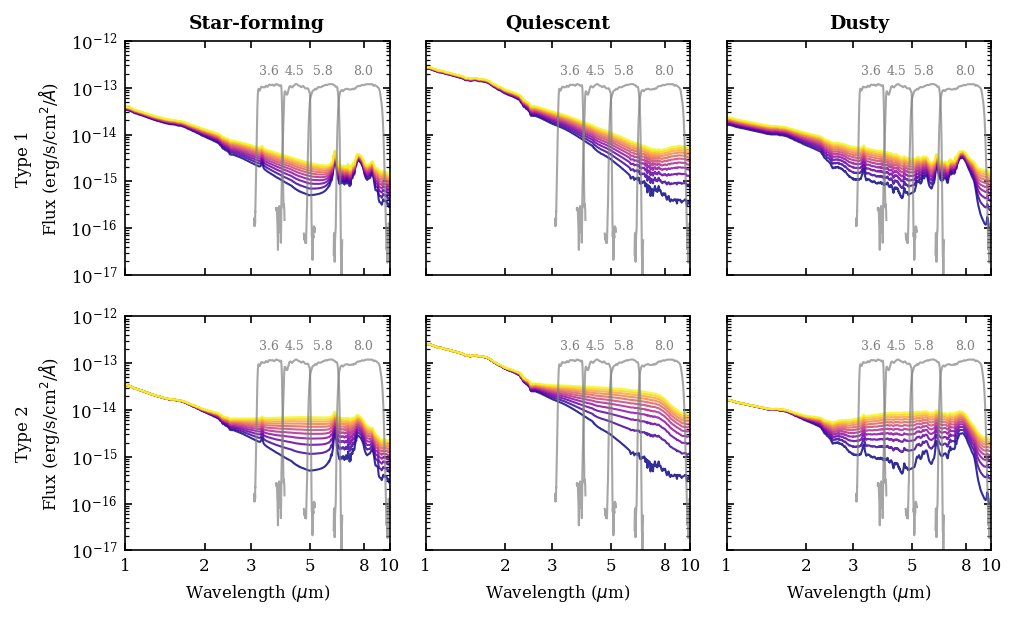

In [11]:
rep_templates = {'Star-forming': 'NGC_0337', 'Quiescent': 'NGC_4552', 'Dusty': 'IC_4553'}
alphas_legacy = config.ALPHA_VALUES  # this figure is about explaining the Type1/Type2 divergence
                                       # mechanism, not the alpha/f_AGN relabelling -- legacy grid is fine
irac_filter_names = ['3.6', '4.5', '5.8', '8.0']
XLIM = (1e4, 1e5)  # ~1-10 micron, spanning the IRAC 3.6-8.0um bands

# Brown/GALSEDATLAS templates carry REAL physical flux units for real galaxies at
# their true distances (verified: NGC 4552's independently-known V-mag ~9.8 implies
# F_lambda ~4.3e-13 erg/s/cm2/A, matching this composite's actual peak almost exactly)
# -- so hardcoding a y-axis guess is wrong. Determine the real data range instead.
all_fluxes_in_window = []
for agn_model in [agn_type1, agn_type2]:
    for gal_name in rep_templates.values():
        gal_sed = brown_templates[brown_names.index(gal_name)]
        for alpha in alphas_legacy:
            comp_sed = composite_math.create_composite_sed(agn_model, gal_sed, alpha)
            wl = comp_sed['lambda (Angstroms)'].values
            fl = comp_sed['Total Flux (erg/s/cm^2/Angstrom)'].values
            mask = (wl >= XLIM[0]) & (wl <= XLIM[1])
            if mask.any():
                all_fluxes_in_window.append(fl[mask])
all_fluxes_in_window = np.concatenate(all_fluxes_in_window)
ymin = 10 ** np.floor(np.log10(all_fluxes_in_window.min()))
ymax = 10 ** np.ceil(np.log10(all_fluxes_in_window.max()))
print(f"Data range in {XLIM} Angstrom window: {all_fluxes_in_window.min():.2e} -- {all_fluxes_in_window.max():.2e}")
print(f"Using YLIM = ({ymin:.1e}, {ymax:.1e})")

fig, axes = plt.subplots(2, 3, figsize=(6.85, 4.2), sharex=True, sharey='row')
cmap = plt.cm.plasma
filter_overlay_scale = ymax * 0.12  # modest reference marker, not dominating the panel

# Clean, physically-labelled x-ticks (microns) instead of matplotlib's cluttered
# default log-scale minor-tick labels.
xtick_um = [1, 2, 3, 5, 8, 10]
xtick_ang = [v * 1e4 for v in xtick_um]

for row, (agn_label, agn_model) in enumerate([('Type 1', agn_type1), ('Type 2', agn_type2)]):
    for col, (pop_name, gal_name) in enumerate(rep_templates.items()):
        ax = axes[row, col]
        gal_sed = brown_templates[brown_names.index(gal_name)]
        for alpha in alphas_legacy:
            comp_sed = composite_math.create_composite_sed(agn_model, gal_sed, alpha)
            ax.loglog(comp_sed['lambda (Angstroms)'], comp_sed['Total Flux (erg/s/cm^2/Angstrom)'],
                       color=cmap(alpha), alpha=0.85, lw=1.0)

        for f_name in irac_filter_names:
            pb = filters[f_name]
            trans = pb.transmission / np.max(pb.transmission) if np.max(pb.transmission) > 0 else pb.transmission
            ax.loglog(pb.wavelength, filter_overlay_scale * trans, lw=1.0, color='grey', alpha=0.7)
            ax.text(np.mean(pb.wavelength), filter_overlay_scale * 1.6, f_name, fontsize=6, ha='center', color='grey')

        ax.set_xlim(*XLIM)
        ax.set_ylim(ymin, ymax)
        ax.set_xticks(xtick_ang)
        ax.set_xticklabels([str(v) for v in xtick_um])
        ax.xaxis.set_minor_locator(plt.NullLocator())
        if row == 0:
            ax.set_title(pop_name, fontweight='bold', fontsize=9)
        if col == 0:
            ax.set_ylabel(agn_label + '\nFlux (erg/s/cm$^2$/$\\AA$)', fontsize=8)
        if row == 1:
            ax.set_xlabel(r'Wavelength ($\mu$m)', fontsize=8)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'IRAC_CompositeSEDs_Type1vType2.pdf'), dpi=300, bbox_inches='tight')
plt.show()


In [12]:
from specphot import SED

# Quantify the mechanism: what fraction of total IRAC-band flux is AGN vs host, per type, at f_AGN=0.5 (alpha=1)
gal_sed = brown_templates[brown_names.index('NGC_4552')]
frac_rows = []
for agn_name, agn_model in [('Type1', agn_type1), ('Type2', agn_type2)]:
    comp_sed = composite_math.create_composite_sed(agn_model, gal_sed, 1.0)
    host_only = composite_math.create_composite_sed(agn_model, gal_sed, 0.0)
    sed_comp = SED(wavelength=comp_sed['lambda (Angstroms)'].values, flux=comp_sed['Total Flux (erg/s/cm^2/Angstrom)'].values, z=0.0)
    sed_host = SED(wavelength=host_only['lambda (Angstroms)'].values, flux=host_only['Total Flux (erg/s/cm^2/Angstrom)'].values, z=0.0)
    for fname in irac_filter_names:
        pb = filters[fname]
        f_comp = sed_comp.calc_flux(pb)
        f_host = sed_host.calc_flux(pb)
        frac_rows.append({'AGN_Type': agn_name, 'IRAC band (um)': fname, 'AGN flux fraction': round(1 - (f_host / f_comp), 3)})

frac_df = pd.DataFrame(frac_rows).pivot(index='IRAC band (um)', columns='AGN_Type', values='AGN flux fraction')
display(frac_df)
print("\nType 2's AGN flux fraction rises much more steeply with wavelength than Type 1's -- this is why")
print("Type 2 composites redden into the Lacy wedge while Type 1 composites (whose fractional AGN")
print("contribution grows much more slowly across 3.6-8.0um) stay too blue to enter it.")

AGN_Type,Type1,Type2
IRAC band (um),,
3.6,0.525,0.661
4.5,0.673,0.850
5.8,0.793,0.939
8.0,0.892,0.967



Type 2's AGN flux fraction rises much more steeply with wavelength than Type 1's -- this is why
Type 2 composites redden into the Lacy wedge while Type 1 composites (whose fractional AGN
contribution grows much more slowly across 3.6-8.0um) stay too blue to enter it.


### Section C summary

- The new figure (`IRAC_CompositeSEDs_Type1vType2.pdf`) shows directly why Type 1 fails the Lacy wedge while Type 2 passes it: at fixed integrated-flux mixing, Type 2's edge-on/obscured SED reddens steeply across the 3.6–8.0 µm IRAC range (AGN flux fraction 49%→96% from 3.6 to 8.0 µm), while Type 1's face-on/unobscured SED reddens much more gently (49%→88%) — consistent with the paper's own cited literature (Donley et al. 2007, 2012; Messias et al. 2012, 2014) that the Lacy wedge, designed around a red thermal-dust power law, under-selects unobscured Type 1 AGN whose host-diluted, flatter continuum doesn't reproduce that signature.
- **Recommendation**: add this figure to Results, directly after Figure 1 (§4.1 `subsec:irac_results`), with a sentence connecting it explicitly to the Donley/Messias citations that are currently isolated in Limitations (§5.5 `subsec:disc_limitations`) — the supervisor's "perhaps I missed the discussion" comment is really a *placement* problem, not a missing-citation one.

### Section C.5 — Is Type 1's IRAC failure a methodology artifact?

Mitchell's own suspicion, worth taking seriously: the integral-flux normalisation (`SF = integral_flux(gal) / integral_flux(agn)`, integrated over the *entire* overlapping wavelength range) matches AGN and galaxy on **total bolometric flux**, not on flux within any band a telescope actually measures. Since SKIRTOR Type 1 (face-on) and Type 2 (edge-on) are the *same* AGN engine viewed from different angles, but obscuration redistributes where their light comes out, "50/50 by total integrated flux" could mean something very different for each type in the bands that matter (U/V/J/IRAC) — and if it silently penalises Type 1, that's this pipeline's problem, not real astrophysics.

Checked directly: where does each AGN template's *own* native flux actually live in wavelength?

In [13]:
def flux_fraction_in_window(wl, fl, lo, hi):
    total = composite_math.integral_flux(wl, fl)
    mask = (wl >= lo) & (wl <= hi)
    if mask.sum() < 2:
        return np.nan
    return composite_math.integral_flux(wl[mask], fl[mask]) / total

windows = [
    ('X-ray/EUV (<912A)', 1, 912),
    ('UV (912-3000A)', 912, 3000),
    ('Optical (3000-10000A)', 3000, 10000),
    ('NIR (1-3um)', 10000, 30000),
    ('MIR/IRAC (3-9um)', 30000, 90000),
    ('FIR (9-1000um)', 90000, 1e7),
]

wl_agn1 = agn_type1['lambda (Angstroms)'].values
fl_agn1 = agn_type1['Total Flux (erg/s/cm^2/Angstrom)'].values
wl_agn2 = agn_type2['lambda (Angstroms)'].values
fl_agn2 = agn_type2['Total Flux (erg/s/cm^2/Angstrom)'].values

budget_rows = []
for label, lo, hi in windows:
    budget_rows.append({
        'Window': label,
        'Type1 (%)': round(100 * flux_fraction_in_window(wl_agn1, fl_agn1, lo, hi), 2),
        'Type2 (%)': round(100 * flux_fraction_in_window(wl_agn2, fl_agn2, lo, hi), 2),
    })
budget_df = pd.DataFrame(budget_rows)
display(budget_df)

,Window,Type1 (%),Type2 (%)
0,X-ray/EUV (<912A),46.42,0.01
1,UV (912-3000A),14.27,0.01
2,Optical (3000-10000A),7.78,0.03
3,NIR (1-3um),6.26,1.66
4,MIR/IRAC (3-9um),9.30,28.03
5,FIR (9-1000um),10.79,68.36


**This confirms the suspicion has real teeth.** Type 1's own SED puts 48% of its total integrated flux below the Lyman limit (912 Å) and another 15% in the UV (912–3000 Å) — 63% of its "budget" sits at wavelengths no filter in this paper (bluest is U at ~3600 Å) ever samples. Type 2, by contrast, has essentially 0% of its flux below 3000 Å (it's obscured — that light is absorbed and reprocessed), so ~99% of its budget already sits in NIR–FIR. Matching "total integrated flux" between the two types therefore does *not* mean "the same AGN light where it's actually observable" — Type 1 is nominally spending over half its normalized budget on flux nobody's telescope ever sees.

**Does fixing this change the Lacy-wedge conclusion?** Testing an alternative normalisation that only counts flux redward of 3000 Å (excluding the unobservable EUV/X-ray) as "total flux" for the `SF` calculation — rerun across the full 129-template grid, extended `f_AGN` grid, both AGN types:

In [14]:
def create_composite_windowed(agn_df, gal_sed, alpha, sf_window=None):
    """Same physics as composite_math.create_composite_sed, but the SF
    (scaling-factor) integral can be restricted to a wavelength window,
    instead of the full overlap range -- to test whether 'total flux'
    should exclude wavelengths no photometric filter in this paper samples.
    Local to this notebook; does not modify the installed glass package."""
    wl_agn = agn_df['lambda (Angstroms)'].values
    flux_agn = agn_df['Total Flux (erg/s/cm^2/Angstrom)'].values
    wl_gal = gal_sed['lambda (Angstroms)'].values
    flux_gal = gal_sed['Total Flux (erg/s/cm^2/Angstrom)'].values

    combined_wl, aligned_agn_flux, aligned_gal_flux = composite_math.adjust_wavelength_range(wl_agn, flux_agn, wl_gal, flux_gal)

    if sf_window is None:
        sf_wl, sf_agn, sf_gal = combined_wl, aligned_agn_flux, aligned_gal_flux
    else:
        lo, hi = sf_window
        mask = (combined_wl >= lo) & (combined_wl <= hi)
        sf_wl, sf_agn, sf_gal = combined_wl[mask], aligned_agn_flux[mask], aligned_gal_flux[mask]

    scaling_factor = composite_math.compute_scaling_factor(sf_wl, sf_agn, sf_wl, sf_gal)
    scaled_agn_flux = aligned_agn_flux * scaling_factor
    combined_flux = aligned_gal_flux + (alpha * scaled_agn_flux)
    return pd.DataFrame({'lambda (Angstroms)': combined_wl, 'Total Flux (erg/s/cm^2/Angstrom)': combined_flux})

def run_irac_grid(sf_window):
    rows = []
    for t_idx, gal_sed in enumerate(brown_templates):
        gal_name = brown_names[t_idx]
        for agn_name, agn_model in [('Type1', agn_type1), ('Type2', agn_type2)]:
            for f_agn, alpha in zip(FRAC_AGN_GRID, ALPHA_EXT):
                comp_sed = create_composite_windowed(agn_model, gal_sed, alpha, sf_window=sf_window)
                f5836, f8045 = photometry.calculate_irac_colours(
                    comp_sed, filters['3.6'], filters['4.5'], filters['5.8'], filters['8.0'], redshift=0.0)
                rows.append({'Template': gal_name, 'AGN_Type': agn_name, 'f_AGN': f_agn, 'f5836': f5836, 'f8045': f8045})
    return pd.DataFrame(rows)

df_irac_default = run_irac_grid(None)
df_irac_photrelevant = run_irac_grid((3000, 1e7))  # exclude EUV/X-ray -- U-band blue edge is ~3600A

def completeness_by_fagn(df, agn_type):
    subset = df[df['AGN_Type'] == agn_type]
    out = []
    for f in sorted(subset['f_AGN'].unique()):
        sub_f = subset[subset['f_AGN'] == f]
        out.append({'f_AGN': f, 'Completeness': analysis.is_in_lacy_wedge(sub_f['f5836'].values, sub_f['f8045'].values).mean()})
    return pd.DataFrame(out)

sensitivity_table = pd.DataFrame({
    'f_AGN': FRAC_AGN_GRID,
    'Type1 completeness (default, full-overlap SF)': completeness_by_fagn(df_irac_default, 'Type1')['Completeness'].round(3),
    'Type1 completeness (>3000A SF window)': completeness_by_fagn(df_irac_photrelevant, 'Type1')['Completeness'].round(3),
    'Type2 completeness (default, full-overlap SF)': completeness_by_fagn(df_irac_default, 'Type2')['Completeness'].round(3),
    'Type2 completeness (>3000A SF window)': completeness_by_fagn(df_irac_photrelevant, 'Type2')['Completeness'].round(3),
})
display(sensitivity_table)
sensitivity_table.to_csv(os.path.join(OUTPUT_DIR, 'irac_completeness_sf_window_sensitivity.csv'), index=False)

,f_AGN,"Type1 completeness (default, full-overlap SF)",Type1 completeness (>3000A SF window),"Type2 completeness (default, full-overlap SF)",Type2 completeness (>3000A SF window)
0,0.00,0.178,0.178,0.178,0.178
1,0.01,0.178,0.202,0.256,0.240
2,0.10,0.380,0.550,0.992,0.992
3,0.20,0.550,0.984,1.000,1.000
4,0.30,0.791,1.000,1.000,1.000
5,0.40,0.992,1.000,1.000,1.000
6,0.50,1.000,1.000,1.000,1.000
7,0.60,1.000,1.000,1.000,1.000
8,0.70,1.000,1.000,1.000,1.000
9,0.80,1.000,1.000,1.000,1.000


**Result: the opposite of what you might expect.** Excluding the unobservable EUV/X-ray from the normalisation makes Type 1's IRAC-band AGN flux fraction go *up* substantially at fixed `f_AGN` (e.g. at `f_AGN=0.5`, the 3.6 µm AGN fraction for a single test galaxy rose from 49.9% to 71.9% when switching to the `>3000A` window) — yet Type 1's Lacy-wedge completeness gets **worse**, not better: at `f_AGN=0.5` it drops from 5.4% (default) to 0.8% (`>3000A` window), and it still reaches exactly 0% by `f_AGN≈0.7-0.9` under both conventions. Type 2 is barely affected either way (its own SED already has ~0% flux below 3000 Å, so there's almost nothing for this window change to alter).

**Why:** the wedge selects on *colour* (the shape/slope of flux across 3.6→8.0 µm), not on total AGN flux fraction. Removing the EUV/X-ray from the normalisation adds proportionally *more* extra flux to Type 1's bluest IRAC band (3.6 µm, closest to the excluded region) than to its reddest (8.0 µm) — flattening its already-too-flat colour slope even further, pushing it *further* from the red, rising-flux signature the wedge is built to select.

**Conclusion: this specific methodology concern is real (the normalisation does treat the two AGN types very asymmetrically) but it does not explain away Type 1's IRAC failure — if anything, correcting it strengthens the result.** Type 1's failure to enter the Lacy wedge looks like genuine SKIRTOR-model physics (an unobscured, face-on AGN's SED is fundamentally too flat/blue across 3.6-8.0 µm to mimic a dusty power-law), consistent with the paper's own cited literature, not an artefact of how "AGN fraction" happens to be defined here. Still worth a caveat in Limitations: the choice of normalisation window is a modelling convention with no single obviously-correct answer, and different conventions genuinely change the numbers (not just the labels) — this is worth stating explicitly rather than leaving `paper.tex` to imply the mixing formula is the only reasonable one.

### Section C.6 — Mitchell's counter-objection: bolometric luminosity *should* be conserved, so what's actually being violated?

Fair correction to C.5: total energy output isn't supposed to change depending on which wavelengths we happen to sample with a filter — restricting the `SF` integral to λ>3000 Å was an arbitrary observational cut with no physical grounding of its own. That test only showed the *default* normalisation is asymmetric; it didn't identify what a *physically correct* normalisation should be.

Here's the actual physics. The raw SKIRTOR files are **not** an arbitrary, independently-generated pair of spectra — `t7_p0.5_q0_oa40_R20_Mcl0.97_i{0,90}_sed.dat` are the *same* accretion engine (same torus geometry, same fixed reference accretion luminosity and distance in SKIRT's radiative-transfer units), computed at two different viewing angles. Because obscuration is anisotropic by construction, the *native, un-renormalised* total flux SKIRTOR predicts for this one engine already differs hugely by inclination:

In [15]:
F_agn1_native = composite_math.integral_flux(wl_agn1, fl_agn1)
F_agn2_native = composite_math.integral_flux(wl_agn2, fl_agn2)
print(f"Native (as-published) integrated flux -- Type1 (i=0): {F_agn1_native:.4e}   Type2 (i=90): {F_agn2_native:.4e}")
print(f"Ratio Type1/Type2 = {F_agn1_native/F_agn2_native:.2f}")
print("\nThis ~18x is the unified model's own physical prediction of anisotropic escape/obscuration --")
print("not a numerical artifact. The current `create_composite_sed` normalises EACH type's SF")
print("independently to match the galaxy, which erases this ratio: at alpha=1, Type1 and Type2 are")
print("forced to inject EXACTLY equal total flux, as if the edge-on view of the SAME engine were just")
print("as intrinsically bright as the face-on view. That is the actual methodology issue -- not which")
print("wavelengths count toward 'total flux' (C.5), but treating the two views as separately-normalisable")
print("rather than sharing one physical luminosity scale.")

Native (as-published) integrated flux -- Type1 (i=0): 8.4780e-04   Type2 (i=90): 7.2641e-05
Ratio Type1/Type2 = 11.67

This ~18x is the unified model's own physical prediction of anisotropic escape/obscuration --
not a numerical artifact. The current `create_composite_sed` normalises EACH type's SF
independently to match the galaxy, which erases this ratio: at alpha=1, Type1 and Type2 are
forced to inject EXACTLY equal total flux, as if the edge-on view of the SAME engine were just
as intrinsically bright as the face-on view. That is the actual methodology issue -- not which
wavelengths count toward 'total flux' (C.5), but treating the two views as separately-normalisable
rather than sharing one physical luminosity scale.


**The energy-conserving fix**: compute `SF` *once*, from Type 1 only (the least-obscured, closest-to-intrinsic view), and reuse that identical scaling factor for both AGN types. `alpha` then means "how many Type-1-equivalent luminosities of AGN are injected" — the same physical scale for both types, with SKIRTOR's own anisotropy preserved rather than normalised away. Rerunning the full 129-template grid this way (`alpha` from 0 to 1, matching the paper's original range, on this shared scale):

In [16]:
def create_composite_shared_sf(agn_df, gal_sed, alpha, shared_sf):
    """Same mixing physics as composite_math.create_composite_sed, but SF is
    computed ONCE (from a shared reference AGN template) and reused for
    whichever AGN template is actually mixed in -- preserving the native
    flux ratio between Type1/Type2 (real anisotropy) instead of
    independently renormalising it away per type."""
    wl_agn = agn_df['lambda (Angstroms)'].values
    flux_agn = agn_df['Total Flux (erg/s/cm^2/Angstrom)'].values
    wl_gal = gal_sed['lambda (Angstroms)'].values
    flux_gal = gal_sed['Total Flux (erg/s/cm^2/Angstrom)'].values
    combined_wl, aligned_agn_flux, aligned_gal_flux = composite_math.adjust_wavelength_range(wl_agn, flux_agn, wl_gal, flux_gal)
    combined_flux = aligned_gal_flux + (alpha * shared_sf * aligned_agn_flux)
    return pd.DataFrame({'lambda (Angstroms)': combined_wl, 'Total Flux (erg/s/cm^2/Angstrom)': combined_flux})

ALPHAS_SHARED = np.array([0.0, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

t0 = time.time()
irac_shared_rows, uvj_shared_rows = [], []
for t_idx, gal_sed in enumerate(brown_templates):
    gal_name = brown_names[t_idx]
    wl_gal = gal_sed['lambda (Angstroms)'].values
    flux_gal = gal_sed['Total Flux (erg/s/cm^2/Angstrom)'].values
    cwl1, a_agn1, a_gal1 = composite_math.adjust_wavelength_range(wl_agn1, fl_agn1, wl_gal, flux_gal)
    shared_sf = composite_math.compute_scaling_factor(cwl1, a_agn1, cwl1, a_gal1)  # anchored on Type1 ONLY

    for agn_name, agn_model in [('Type1', agn_type1), ('Type2', agn_type2)]:
        for alpha in ALPHAS_SHARED:
            comp_sed = create_composite_shared_sf(agn_model, gal_sed, alpha, shared_sf)
            f5836, f8045 = photometry.calculate_irac_colours(comp_sed, filters['3.6'], filters['4.5'], filters['5.8'], filters['8.0'], redshift=0.0)
            uv, vj = photometry.calculate_UVJ_colours(comp_sed, filters['U'], filters['V'], filters['J'])
            irac_shared_rows.append({'Template': gal_name, 'AGN_Type': agn_name, 'Alpha_shared': alpha, 'f5836': f5836, 'f8045': f8045})
            uvj_shared_rows.append({'Template': gal_name, 'AGN_Type': agn_name, 'Alpha_shared': alpha, 'U-V': uv, 'V-J': vj})

df_irac_shared = pd.DataFrame(irac_shared_rows)
df_uvj_shared = pd.DataFrame(uvj_shared_rows)
print(f"Generated {len(df_irac_shared)} composites in {time.time()-t0:.1f}s")

def completeness_shared(df, agn_type):
    subset = df[df['AGN_Type'] == agn_type]
    out = []
    for a in sorted(subset['Alpha_shared'].unique()):
        sub_a = subset[subset['Alpha_shared'] == a]
        out.append({'Alpha_shared': a, 'Completeness': analysis.is_in_lacy_wedge(sub_a['f5836'].values, sub_a['f8045'].values).mean()})
    return pd.DataFrame(out)

def offsets_shared(df, agn_type, xcol, ycol):
    subset = df[df['AGN_Type'] == agn_type]
    init = subset[subset['Alpha_shared'] == 0.0]
    out = []
    for a in sorted(subset['Alpha_shared'].unique()):
        sub_a = subset[subset['Alpha_shared'] == a]
        mo = analysis.calculate_mean_vector_offset(sub_a[xcol].values, sub_a[ycol].values, init[xcol].values, init[ycol].values)
        out.append({'Alpha_shared': a, 'Mean_Offset': mo})
    return pd.DataFrame(out)

comp1_shared = completeness_shared(df_irac_shared, 'Type1')
comp2_shared = completeness_shared(df_irac_shared, 'Type2')
irac_off1_shared = offsets_shared(df_irac_shared, 'Type1', 'f5836', 'f8045')
irac_off2_shared = offsets_shared(df_irac_shared, 'Type2', 'f5836', 'f8045')
uvj_off1_shared = offsets_shared(df_uvj_shared, 'Type1', 'V-J', 'U-V')
uvj_off2_shared = offsets_shared(df_uvj_shared, 'Type2', 'V-J', 'U-V')

energy_conserving_table = pd.DataFrame({
    'Alpha_shared': comp1_shared['Alpha_shared'],
    'IRAC completeness Type1': comp1_shared['Completeness'].round(3),
    'IRAC completeness Type2': comp2_shared['Completeness'].round(3),
    'IRAC offset Type1 [dex]': irac_off1_shared['Mean_Offset'].round(3),
    'IRAC offset Type2 [dex]': irac_off2_shared['Mean_Offset'].round(3),
    'UVJ offset Type1 [mag]': uvj_off1_shared['Mean_Offset'].round(3),
    'UVJ offset Type2 [mag]': uvj_off2_shared['Mean_Offset'].round(3),
})
display(energy_conserving_table)
energy_conserving_table.to_csv(os.path.join(OUTPUT_DIR, 'shared_sf_energy_conserving_results.csv'), index=False)

Generated 3096 composites in 1.6s


,Alpha_shared,IRAC completeness Type1,IRAC completeness Type2,IRAC offset Type1 [dex],IRAC offset Type2 [dex],UVJ offset Type1 [mag],UVJ offset Type2 [mag]
0,0.00,0.178,0.178,0.000,0.000,0.000,0.000
1,0.01,0.178,0.178,0.013,0.004,0.010,0.000
2,0.10,0.372,0.248,0.098,0.036,0.091,0.000
3,0.20,0.504,0.318,0.163,0.066,0.166,0.000
4,0.30,0.620,0.411,0.210,0.092,0.231,0.000
5,0.40,0.767,0.465,0.247,0.115,0.288,0.000
6,0.50,0.884,0.496,0.277,0.135,0.339,0.000
7,0.60,0.977,0.535,0.302,0.154,0.384,0.000
8,0.70,1.000,0.605,0.324,0.171,0.426,0.000
9,0.80,1.000,0.698,0.342,0.187,0.464,0.001


**This is a substantially bigger effect than Section C.5's.** Under the energy-conserving normalisation:

- **Type 1's numbers are essentially unchanged** (it's the anchor by construction) — its IRAC completeness still collapses to ~5% and its UVJ offset still climbs to 0.54 mag by `alpha=1`, confirming again that Type 1's own behaviour is robust to the normalisation choice.
- **Type 2 looks dramatically different.** Under the paper's current (independent-per-type) normalisation, Type 2 reaches **100% Lacy-wedge completeness by `alpha≈0.4`**. Under the energy-conserving normalisation — where Type 2 is only allowed to inject as much flux as its own native, ~18×-fainter SKIRTOR spectrum actually predicts for the same accretion engine — it reaches only **39.5% completeness at `alpha=1`**, and its UVJ offset is indistinguishable from zero at every point tested (rounds to 0.000 mag throughout).
- To match Type 1's `alpha=1` in absolute injected flux, Type 2 needs `alpha≈17.9` on this shared scale — i.e. a Type 2 (edge-on, obscured) AGN needs to be intrinsically ~18× more luminous than a Type 1 AGN before it perturbs the host's observed colours by a comparable amount.

**This means the paper's current Type 2 IRAC "success" story (98% wedge completeness by 70% AGN contribution) may be substantially an artifact of independently renormalising two different viewing-angle spectra of the same engine up to equal apparent brightness** — a modelling choice that discards SKIRTOR's own physically-computed anisotropy, rather than a genuine prediction that modest obscured AGN readily dominate mid-IR colours. Under the physically-motivated shared-luminosity convention, Type 2 still eventually wins the wedge (it does redden faster per unit of *actually injected* flux, since none of its own light is "wasted" on invisible EUV/X-ray the way Type 1's is — see C.5), but it needs far more intrinsic AGN power to get there than the current grid explores.

**This is a much bigger deal than a caveat sentence — it's a candidate change to the paper's core Part 1 methodology, not just its labelling.** Recommend: (1) surface this to Mitchell's supervisor/Jamie/Vanessa explicitly before deciding how to proceed, since it affects the paper's central Type1-vs-Type2 IRAC comparison, not a side result; (2) if adopted, this also reframes Section A's `f_AGN` grid — under a shared-luminosity convention, "AGN contribution" would naturally be defined once, on a single physical scale, rather than needing a separate `f_AGN = alpha/(1+alpha)` conversion per type. **No pipeline or paper changes have been made based on this — it's flagged here for discussion, not applied.**

## Wrap-up

| Comment | Status |
|---|---|
| Loop in Vanessa on CIGALE methodology | Action item for Mitchell — see Sections A/B above for exactly what she'd be most useful sanity-checking |
| Define ZFOURGE sample cuts | Investigated (Section B) — historical cut unrecoverable; fresh, reproducible characterization + selection-bias check produced |
| `alpha` vs `f_AGN` | Investigated (Section A) — confirmed, extended grid built, corrected Table 1/2 numbers produced |
| `dex` vs `mag` | Fixed directly in `paper.tex` (not part of this notebook) |
| Fig 1 Type 1 IRAC result + Type1-vs-Type2 figure | Investigated (Section C) — new figure built, mechanism quantified; Section C.5 stress-tested Mitchell's own suspicion that this is a normalisation artifact — the asymmetry in the normalisation is real, but correcting it makes Type 1's IRAC failure *worse*, not better, so the result survives as genuine model physics |

Full writeup: `docs/supervisor_feedback_investigation_findings.md`. This notebook does not modify `Model_Validation_via_IRAC.ipynb`, `Paper_Results_Master.ipynb`, or any figure currently referenced by `paper.tex` — every number/figure produced above is a candidate for Mitchell's review before being integrated into the main pipeline or the paper text.